In [1]:
import os
import json
from dataclasses import dataclass, field
from typing import List

import tensorflow as tf
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet import preprocess_input

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\python\keras\engine\training_arrays_v1.py:37: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.5.3)
  from scipy.sparse import issparse  # pylint: disable=g-import-not-at-top


In [2]:

MODEL_PATH = r"C:\Users\HP\Downloads\modelF\best_model FF.keras"

model = tf.keras.models.load_model(MODEL_PATH)

IMG_SIZE = 380

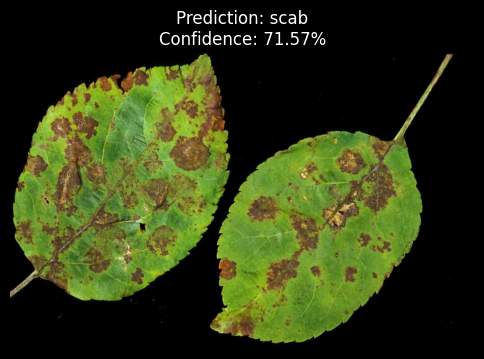

Disease         : Apple Scab
Predicted Class : scab
Confidence      : 71.57% (Moderate confidence — visual confirmation is recommended before chemical treatment.)
Severity        : high
Urgency         : Spreads rapidly in cool, wet spring weather starting at green tip — act promptly at season start
------------------------------------------------------------
Immediate Actions:
  - Remove and destroy visibly infected leaves
  - Rake and dispose of fallen leaves to cut next season's spore source
Organic Treatment:
  - Sulfur-based fungicide sprays
Chemical Treatment:
  - Captan or mancozeb, starting at bud break and repeated weekly in wet weather
Prevention:
  - Plant scab-resistant varieties
  - Ensure adequate spacing and pruning for airflow
  - Autumn sanitation of fallen leaves


In [ ]:

CLASSES = [
    "complex",
    "frog_eye_leaf_spot",
    "healthy",
    "powdery_mildew",
    "rust",
    "scab"
]

@dataclass
class TreatmentInfo:
    disease_name: str
    severity: str
    urgency: str
    immediate_actions: List[str] = field(default_factory=list)
    organic_treatment: List[str] = field(default_factory=list)
    chemical_treatment: List[str] = field(default_factory=list)
    prevention: List[str] = field(default_factory=list)


TREATMENT_DB = {
    "complex": TreatmentInfo(
        disease_name="Complex (Multiple Diseases)",
        severity="high",
        urgency="Overlapping infections signal heavy disease pressure — inspect closely and act within 2-3 days",
        immediate_actions=[
            "Remove and destroy visibly infected leaves and fruit away from the orchard",
            "Prune out cankered or heavily spotted branches",
            "Inspect the leaf carefully to identify which diseases are present",
        ],
        organic_treatment=[
            "Apply a broad-spectrum copper or sulfur spray while the dominant disease is confirmed",
        ],
        chemical_treatment=[
            "Broad-spectrum protectant fungicide such as captan, then switch to a targeted product once the leading disease is identified",
        ],
        prevention=[
            "Improve airflow through regular pruning",
            "Maintain an orchard sanitation routine (remove mummified fruit and fallen leaves)",
            "Plant multi-disease-resistant apple varieties where possible",
        ],
    ),
    "frog_eye_leaf_spot": TreatmentInfo(
        disease_name="Frog Eye Leaf Spot",
        severity="medium",
        urgency="Spreads by rain-splashed spores starting at petal fall — act within a week",
        immediate_actions=[
            "Remove mummified fruit left on the tree or ground",
            "Prune out cankered branches and destroy them",
        ],
        organic_treatment=[
            "Copper-based fungicide sprays",
        ],
        chemical_treatment=[
            "Captan or thiophanate-methyl, applied from petal fall and repeated every 10-14 days in wet weather",
        ],
        prevention=[
            "Orchard sanitation — remove dead wood, mummies, and fallen fruit",
            "Avoid overhead irrigation to keep foliage dry",
            "Plant resistant varieties where possible",
        ],
    ),
    "healthy": TreatmentInfo(
        disease_name="Healthy",
        severity="low",
        urgency="No action required",
        immediate_actions=["Continue routine monitoring"],
        organic_treatment=[],
        chemical_treatment=[],
        prevention=["Maintain current watering, fertilizing, and pruning practices"],
    ),
    "powdery_mildew": TreatmentInfo(
        disease_name="Powdery Mildew",
        severity="medium",
        urgency="Spreads fastest in warm days with high humidity at night — act within 2-3 days",
        immediate_actions=[
            "Prune out visibly infected shoots and buds",
            "Reduce excess nitrogen fertilization, which favors new susceptible growth",
        ],
        organic_treatment=[
            "Sulfur-based fungicide sprays",
            "Neem oil as a lighter early-season option",
        ],
        chemical_treatment=[
            "Sterol-inhibiting fungicides such as myclobutanil, starting at bud swell and repeated every 7-10 days",
        ],
        prevention=[
            "Prune to improve air circulation around the canopy",
            "Plant mildew-resistant varieties where possible",
        ],
    ),
    "rust": TreatmentInfo(
        disease_name="Cedar-Apple Rust",
        severity="medium",
        urgency="Infects during wet spring weather when nearby juniper galls release spores — act at bud break",
        immediate_actions=[
            "Prune out infected leaves and branches",
            "Remove nearby juniper or cedar galls if feasible",
        ],
        organic_treatment=[
            "Limited organic options are effective once infection is established — prevention is key",
        ],
        chemical_treatment=[
            "Fungicides containing myclobutanil or propiconazole, starting at bud break and repeated every 7-14 days through spring",
        ],
        prevention=[
            "Plant rust-resistant apple varieties",
            "Increase distance from juniper/cedar trees where possible",
        ],
    ),
    "scab": TreatmentInfo(
        disease_name="Apple Scab",
        severity="high",
        urgency="Spreads rapidly in cool, wet spring weather starting at green tip — act promptly at season start",
        immediate_actions=[
            "Remove and destroy visibly infected leaves",
            "Rake and dispose of fallen leaves to cut next season's spore source",
        ],
        organic_treatment=[
            "Sulfur-based fungicide sprays",
        ],
        chemical_treatment=[
            "Captan or mancozeb, starting at bud break and repeated weekly in wet weather",
        ],
        prevention=[
            "Plant scab-resistant varieties",
            "Ensure adequate spacing and pruning for airflow",
            "Autumn sanitation of fallen leaves",
        ],
    ),
}

def get_recommendation(predicted_class: str, confidence: float, medium_conf_threshold: float = 0.85) -> dict:
    if predicted_class not in TREATMENT_DB:
        return {
            "status": "unknown_class",
            "message": "Class not found in the knowledge base — check the class name sent by the model.",
        }

    info = TREATMENT_DB[predicted_class]

    if confidence >= medium_conf_threshold:
        confidence_note = "The model is highly confident."
    else:
        confidence_note = "Moderate confidence — visual confirmation is recommended before chemical treatment."

    return {
        "status": "ok",
        "predicted_class": predicted_class,
        "confidence": confidence,
        "confidence_note": confidence_note,
        "severity": info.severity,
        "disease_name": info.disease_name,
        "urgency": info.urgency,
        "immediate_actions": info.immediate_actions,
        "organic_treatment": info.organic_treatment,
        "chemical_treatment": info.chemical_treatment,
        "prevention": info.prevention,
    }



def preprocess_image(image_path, img_size=IMG_SIZE):
    image = Image.open(image_path).convert("RGB")
    original_image = image.copy()
    resized_image = image.resize((img_size, img_size))
    image_array = np.array(resized_image).astype("float32")
    image_array = preprocess_input(image_array)
    image_array = np.expand_dims(image_array, axis=0)
    return image_array, original_image


def get_top_predictions(predictions, classes, top_k=3):
    top_indices = np.argsort(predictions)[::-1][:top_k]
    return [(classes[i], float(predictions[i])) for i in top_indices]


def display_recommendation(original_image, recommendation, top_predictions):
    plt.figure(figsize=(6, 6))
    plt.imshow(original_image)
    plt.axis("off")

    if recommendation["status"] == "ok":
        plt.title(
            f"Prediction: {recommendation['predicted_class']}\n"
            f"Confidence: {recommendation['confidence'] * 100:.2f}%"
        )
    else:
        plt.title("Prediction Result")

    plt.show()

    print("=" * 60)

    if recommendation["status"] == "unknown_class":
        print(recommendation["message"])
        print("=" * 60)
        return

    print(f"Disease         : {recommendation['disease_name']}")
    print(f"Predicted Class : {recommendation['predicted_class']}")
    print(f"Confidence      : {recommendation['confidence'] * 100:.2f}% ({recommendation['confidence_note']})")
    print(f"Severity        : {recommendation['severity']}")
    print(f"Urgency         : {recommendation['urgency']}")
    print("-" * 60)
    print("Immediate Actions:")
    for action in recommendation["immediate_actions"]:
        print(f"  - {action}")
    print("Organic Treatment:")
    for item in recommendation["organic_treatment"]:
        print(f"  - {item}")
    print("Chemical Treatment:")
    for item in recommendation["chemical_treatment"]:
        print(f"  - {item}")
    print("Prevention:")
    for item in recommendation["prevention"]:
        print(f"  - {item}")
    print("=" * 60)



TEMPERATURE = 0.25

def apply_temperature(probs, temperature=TEMPERATURE, epsilon=1e-8):
    probs = np.clip(probs, epsilon, 1.0)
    logits = np.log(probs)
    scaled_logits = logits / temperature
    exp_logits = np.exp(scaled_logits - np.max(scaled_logits))
    return exp_logits / np.sum(exp_logits)


def predict_image(image_path, top_k=3, show_plot=True, medium_conf_threshold=0.85, temperature=TEMPERATURE):
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found at path: {image_path}")

    image_array, original_image = preprocess_image(image_path)

    raw_predictions = model.predict(image_array, verbose=0)[0]

    predictions = apply_temperature(raw_predictions, temperature=temperature)

    predicted_index = np.argmax(predictions)
    predicted_class = CLASSES[predicted_index]
    confidence = float(predictions[predicted_index])

    top_predictions = get_top_predictions(predictions, CLASSES, top_k)

    recommendation = get_recommendation(predicted_class, confidence, medium_conf_threshold)

    if show_plot:
        display_recommendation(original_image, recommendation, top_predictions)

    return {
        "predicted_class": predicted_class,
        "confidence": confidence,
        "top_predictions": top_predictions,
        "recommendation": recommendation
    }

image_path = r"C:\Users\HP\Downloads\modelF\photo.jfif"

result = predict_image(image_path)

predicted_class = result["predicted_class"]
confidence = result["confidence"]
top_predictions = result["top_predictions"]
recommendation = result["recommendation"]
